# HAM10000 — Pipeline 1: Custom CNN from Scratch
**CSCI323 — UOWD | Team: Husnia + Juria**



In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Sklearn
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize


from google.colab import drive
drive.mount('/content/drive')

print('PyTorch version:', torch.__version__)
print('GPU available:', torch.cuda.is_available())
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using:', DEVICE)

Mounted at /content/drive
PyTorch version: 2.11.0+cu128
GPU available: True
Using: cuda


In [ ]:

PROJECT = '/content/drive/MyDrive/323_proj/PROJ_FILRS'

train_df = pd.read_csv(f'{PROJECT}/augmented_train_split.csv')
val_df   = pd.read_csv(f'{PROJECT}/val_split.csv')
test_df  = pd.read_csv(f'{PROJECT}/test_split.csv')


meta_cleaned = pd.read_csv(f'{PROJECT}/HAM10000_metadata_cleaned.csv')[['image_id', 'age', 'sex']]

def merge_clean_meta(df):
    df = df.drop(columns=['age', 'sex'], errors='ignore')
    df = df.merge(meta_cleaned, on='image_id', how='left')
    df['age'] = df['age'].fillna(meta_cleaned['age'].median())
    df['sex'] = df['sex'].fillna('unknown')
    return df

train_df = merge_clean_meta(train_df)
val_df   = merge_clean_meta(val_df)
test_df  = merge_clean_meta(test_df)

for df in [train_df, val_df, test_df]:
    df['sex'] = df['sex'].fillna('unknown').astype(str).str.lower().str.strip()

BASE_1 = f'{PROJECT}/HAM10000_images_part_1'
BASE_2 = f'{PROJECT}/HAM10000_images_part_2'

def fix_path(p):
    fname = re.search(r'(ISIC_\d+\.jpg)', str(p))
    if not fname:
        return p
    fname = fname.group(1)
    return f'{BASE_1}/{fname}' if 'part_1' in str(p) else f'{BASE_2}/{fname}'

for df in [train_df, val_df, test_df]:
    df['filepath'] = df['filepath'].apply(fix_path)

# Check
missing = train_df[~train_df['filepath'].apply(os.path.exists)]
print(f'Missing in train: {len(missing)}')
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print(f'NaN age in train: {train_df["age"].isna().sum()}')
print(f'Example path: {train_df["filepath"].iloc[0]}')


Missing in train: 0
Train: 8190 | Val: 1464 | Test: 1497
NaN age in train: 0
Example path: /content/drive/MyDrive/323_proj/PROJ_FILRS/HAM10000_images_part_1/ISIC_0027419.jpg


In [ ]:
class FeatureTransformer(BaseEstimator, TransformerMixin):
    """
    Preprocesses patient metadata using ColumnTransformer.
    - StandardScaler on numerical columns (age)
    - OneHotEncoder on categorical columns (sex)
    Exactly matches the professor's FeatureTransformer pattern.
    """

    def __init__(self):
        self.preprocessor = None

    def fit(self, X, y=None):
        categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
        numeric_cols     = X.select_dtypes(include=['number']).columns.tolist()

        print(f'Numerical columns:   {numeric_cols}')
        print(f'Categorical columns: {categorical_cols}')

        self.preprocessor = ColumnTransformer(
            transformers=[
                ('num', StandardScaler(), numeric_cols),
                ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'),
                 categorical_cols),
            ]
        )
        self.preprocessor.fit(X)
        return self

    def transform(self, X):
        return self.preprocessor.transform(X)


# Loc columns are already binary encoded
META_RAW_COLS = ['age', 'sex']
LOC_COLS = [c for c in train_df.columns if c.startswith('loc_')]
print('Loc columns found:', LOC_COLS)

# Encode labels
le = LabelEncoder()
le.fit(train_df['dx'])
for df in [train_df, val_df, test_df]:
    df['label'] = le.transform(df['dx'])

print(f'\nClasses: {list(le.classes_)}')
print(f'Label mapping: {dict(zip(le.classes_, range(len(le.classes_))))}')

# Fit FeatureTransformer on train only (no leakage)
ft = FeatureTransformer()
ft.fit(train_df[META_RAW_COLS])

# Transform all splits
train_meta = np.hstack([
    ft.transform(train_df[META_RAW_COLS]),
    train_df[LOC_COLS].values
]).astype(np.float32)

val_meta = np.hstack([
    ft.transform(val_df[META_RAW_COLS]),
    val_df[LOC_COLS].values
]).astype(np.float32)

test_meta = np.hstack([
    ft.transform(test_df[META_RAW_COLS]),
    test_df[LOC_COLS].values
]).astype(np.float32)

META_DIM = train_meta.shape[1]
print(f'\nMetadata feature dimensions: {META_DIM}')

# Class weights for imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(7),
    y=train_df['label'].values
)
print('\nClass weights:')
for i, cls in enumerate(le.classes_):
    print(f'  [{i}] {cls:<8} → weight = {class_weights[i]:.3f}')

Loc columns found: ['loc_abdomen', 'loc_acral', 'loc_back', 'loc_chest', 'loc_ear', 'loc_face', 'loc_foot', 'loc_genital', 'loc_hand', 'loc_lower extremity', 'loc_neck', 'loc_scalp', 'loc_trunk', 'loc_unknown', 'loc_upper extremity']

Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Label mapping: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
Numerical columns:   ['age']
Categorical columns: ['sex']

Metadata feature dimensions: 18

Class weights:
  [0] akiec    → weight = 3.232
  [1] bcc      → weight = 2.233
  [2] bkl      → weight = 1.187
  [3] df       → weight = 3.900
  [4] mel      → weight = 1.184
  [5] nv       → weight = 0.247
  [6] vasc     → weight = 3.900


In [ ]:
class SkinLesionDataset(Dataset):
    """
    PyTorch Dataset for HAM10000.
    Loads dermoscopy images + preprocessed metadata.
    Augments training images with flips and brightness jitter.
    """

    def __init__(self, df, metadata, labels, img_size=224, augment=False):
        self.df       = df.reset_index(drop=True)
        self.metadata = metadata
        self.labels   = labels
        self.img_size = img_size
        self.augment  = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load image
        try:
            img = Image.open(row['filepath']).convert('RGB')
            img = img.resize((self.img_size, self.img_size))
            arr = np.array(img, dtype=np.float32) / 255.0
        except Exception:
            arr = np.zeros((self.img_size, self.img_size, 3), dtype=np.float32)

        # ImageNet normalisation
        arr -= np.array([0.485, 0.456, 0.406])
        arr /= np.array([0.229, 0.224, 0.225])

        # Augmentation (training only)
        if self.augment:
            if np.random.rand() > 0.5:
                arr = np.fliplr(arr)
            if np.random.rand() > 0.5:
                arr = np.flipud(arr)
            arr *= np.random.uniform(0.8, 1.2)
            arr = np.clip(arr, -3, 3)

        # (H,W,C) → (C,H,W)
        img_tensor  = torch.tensor(arr.transpose(2, 0, 1), dtype=torch.float32)
        meta_tensor = torch.tensor(self.metadata[idx], dtype=torch.float32)
        label       = torch.tensor(self.labels[idx], dtype=torch.long)

        return img_tensor, meta_tensor, label


train_labels = train_df['label'].values
val_labels   = val_df['label'].values
test_labels  = test_df['label'].values

train_dataset = SkinLesionDataset(train_df, train_meta, train_labels, augment=True)
val_dataset   = SkinLesionDataset(val_df,   val_meta,   val_labels,   augment=False)
test_dataset  = SkinLesionDataset(test_df,  test_meta,  test_labels,  augment=False)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')

# Sanity check
imgs, metas, labels_batch = next(iter(train_loader))
print(f'\nImage batch:    {imgs.shape}')
print(f'Metadata batch: {metas.shape}')
print(f'Labels batch:   {labels_batch.shape}')
print('Dataset ready!')

Train batches: 256
Val batches:   46
Test batches:  47

Image batch:    torch.Size([32, 3, 224, 224])
Metadata batch: torch.Size([32, 18])
Labels batch:   torch.Size([32])
Dataset ready!


In [ ]:
class CustomCNN(nn.Module):
    """
    Pipeline 1: Custom CNN trained from scratch + metadata branch.

    Image branch:    4 conv blocks → GlobalAvgPool → 256-dim embedding
    Metadata branch: 2 FC layers → 32-dim embedding
    Fusion:          concatenate both → classify into 7 classes
    """

    def __init__(self, meta_dim, num_classes=7):
        super(CustomCNN, self).__init__()

        # ── IMAGE BRANCH ──────────────────────────────────────────────────────
        self.image_branch = nn.Sequential(
            # Block 1 — learns edges and basic colour patterns
            nn.Conv2d(3,  32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),           # 224 → 112
            nn.Dropout2d(0.25),

            # Block 2 — learns textures and shapes
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),           # 112 → 56
            nn.Dropout2d(0.25),

            # Block 3 — learns lesion-level features
            nn.Conv2d(64,  128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),           # 56 → 28
            nn.Dropout2d(0.30),

            # Block 4 — learns high-level pathological patterns
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),           # 28 → 14
            nn.Dropout2d(0.30),

            nn.AdaptiveAvgPool2d(1),   # → (batch, 256, 1, 1)
        )
        self.img_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
        )

        # METADATA BRANCH
        self.meta_branch = nn.Sequential(
            nn.Linear(meta_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
        )

        # FUSION HEAD
        self.fusion = nn.Sequential(
            nn.Linear(256 + 32, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )

    def forward(self, img, meta):
        img_feat  = self.img_fc(self.image_branch(img))
        meta_feat = self.meta_branch(meta)
        combined  = torch.cat([img_feat, meta_feat], dim=1)
        return self.fusion(combined)


model = CustomCNN(meta_dim=META_DIM, num_classes=7).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')
print(model)

Total parameters: 1,281,287
CustomCNN(
  (image_branch): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=Fals

In [ ]:
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=4)


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, metas, labels in loader:
        imgs, metas, labels = imgs.to(DEVICE), metas.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs, metas)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, metas, labels in loader:
            imgs, metas, labels = imgs.to(DEVICE), metas.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs, metas)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += labels.size(0)
    return total_loss / len(loader), correct / total


#Training loop
EPOCHS        = 50
best_val_loss = float('inf')
patience_ctr  = 0
PATIENCE      = 8

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

CKPT_PATH = f'{PROJECT}/scratch_model_outputs/best_model.pt'
os.makedirs(f'{PROJECT}/scratch_model_outputs', exist_ok=True)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    va_loss, va_acc = evaluate(model, val_loader, criterion)
    scheduler.step(va_loss)

    train_losses.append(tr_loss); val_losses.append(va_loss)
    train_accs.append(tr_acc);   val_accs.append(va_acc)

    print(f'Epoch {epoch:02d}/{EPOCHS}  '
          f'Train Loss: {tr_loss:.4f}  Train Acc: {tr_acc:.4f}  '
          f'Val Loss: {va_loss:.4f}  Val Acc: {va_acc:.4f}', flush=True)

    if va_loss < best_val_loss:
        best_val_loss = va_loss
        patience_ctr  = 0
        torch.save(model.state_dict(), CKPT_PATH)
        print('  ✓ Saved best model')
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

print('\nTraining complete.')

Classification Report:
              precision    recall  f1-score   support

       akiec       0.30      0.47      0.37        51
         bcc       0.40      0.62      0.49        77
         bkl       0.37      0.38      0.37       157
          df       0.31      0.41      0.35        22
         mel       0.41      0.45      0.43       168
          nv       0.90      0.80      0.85      1000
        vasc       0.33      0.55      0.41        22

    accuracy                           0.69      1497
   macro avg       0.43      0.53      0.47      1497
weighted avg       0.73      0.69      0.70      1497



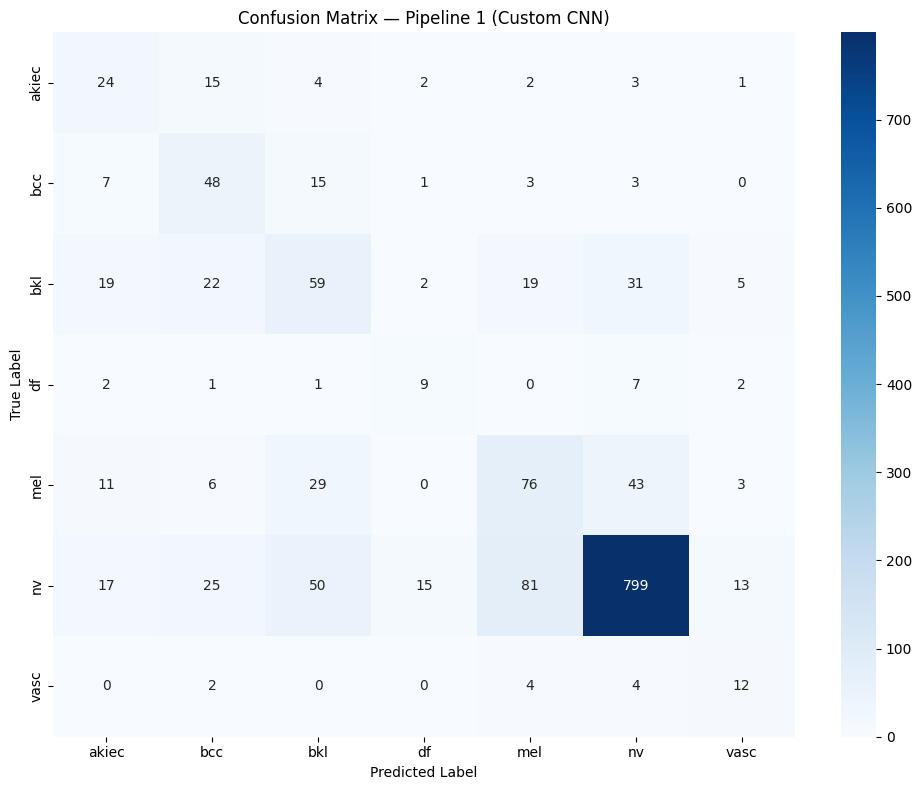

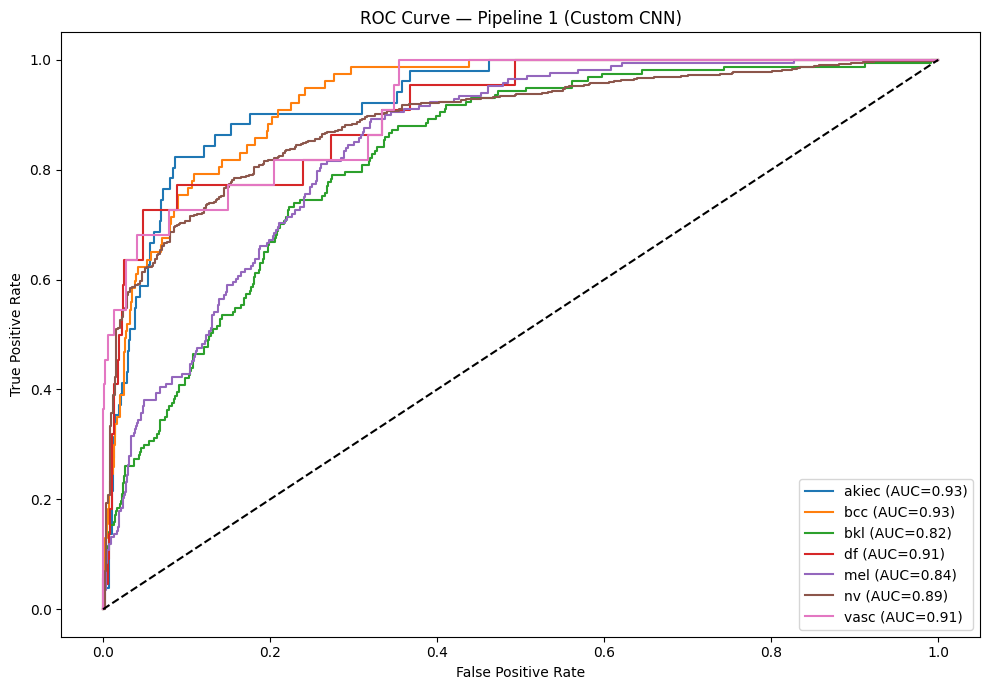

All plots saved to scratch_model_outputs/


In [ ]:
# Load best model
CKPT_PATH = f'{PROJECT}/scratch_model_outputs/best_model.pt'
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for imgs, metas, labels in test_loader:
        imgs, metas = imgs.to(DEVICE), metas.to(DEVICE)
        outputs = model(imgs, metas)
        probs   = torch.softmax(outputs, dim=1).cpu().numpy()
        preds   = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# Classification Report
print('Classification Report:')
print(classification_report(all_labels, all_preds,
                             target_names=le.classes_))

#Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — Pipeline 1 (Custom CNN)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig(f'{PROJECT}/scratch_model_outputs/confusion_matrix.png', dpi=100)
plt.show()

# ROC Curve
y_bin = label_binarize(all_labels, classes=np.arange(7))

plt.figure(figsize=(10, 7))
for i, cls in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, label=f'{cls} (AUC={auc(fpr, tpr):.2f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Pipeline 1 (Custom CNN)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'{PROJECT}/scratch_model_outputs/roc_curve.png', dpi=100)
plt.show()

# Learning Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_losses, label='Train'); ax1.plot(val_losses, label='Val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.plot(train_accs, label='Train'); ax2.plot(val_accs, label='Val')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.suptitle('Pipeline 1 — Custom CNN Training History', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROJECT}/scratch_model_outputs/learning_curves.png', dpi=100)
plt.show()

print('All plots saved to scratch_model_outputs/')

In [ ]:

# Extracts 256-dim image features + 18-dim metadata features for all splits
# and saves them as .npy files so Shri can load and run SVM classification

import numpy as np
import os

FEAT_DIR = f"{PROJECT}/scratch_model_outputs/features"
os.makedirs(FEAT_DIR, exist_ok=True)

# Hook to extract image features before fusion head
def extract_features(model, loader, metadata_array):
    model.eval()
    img_feats  = []
    meta_feats = []
    labels_out = []

    with torch.no_grad():
        for batch_idx, (imgs, metas, labels) in enumerate(loader):
            imgs  = imgs.to(DEVICE)
            metas = metas.to(DEVICE)

            # Extract image features (256-dim) before fusion
            img_feat = model.img_fc(model.image_branch(imgs))  # (B, 256)

            img_feats.extend(img_feat.cpu().numpy())
            meta_feats.extend(metas.cpu().numpy())
            labels_out.extend(labels.numpy())

    img_feats  = np.array(img_feats)
    meta_feats = np.array(meta_feats)
    labels_out = np.array(labels_out)

    # Concatenate image + metadata features → full feature vector
    combined = np.hstack([img_feats, meta_feats])  # (N, 256+18=274)
    return combined, labels_out

# Load best model before extracting
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))

print("Extracting train features...")
train_feats, train_lbls = extract_features(model, train_loader, train_meta)

print("Extracting val features...")
val_feats, val_lbls = extract_features(model, val_loader, val_meta)

print("Extracting test features...")
test_feats, test_lbls = extract_features(model, test_loader, test_meta)

# Save .npy files
np.save(f"{FEAT_DIR}/train_features.npy", train_feats)
np.save(f"{FEAT_DIR}/train_labels.npy",   train_lbls)
np.save(f"{FEAT_DIR}/val_features.npy",   val_feats)
np.save(f"{FEAT_DIR}/val_labels.npy",     val_lbls)
np.save(f"{FEAT_DIR}/test_features.npy",  test_feats)
np.save(f"{FEAT_DIR}/test_labels.npy",    test_lbls)

print(f"Feature shapes:")
print(f" Train : {train_feats.shape}  (256 image + 18 metadata = 274 dims)")
print(f" Val   : {val_feats.shape}")
print(f" Test  : {test_feats.shape}")
print(f"Saved to {FEAT_DIR}")
print("Shri can now load these with np.load()")


In [ ]:
import subprocess
result = subprocess.run(['find', '/content/drive/MyDrive', '-name', 'augmented_train_split.csv'],
                       capture_output=True, text=True)
print(result.stdout)